# EXPLORAÇÃO DE DADOS

## Importando bibliotecas 

In [1]:
import pandas as pd
from pathlib import Path
from ydata_profiling import ProfileReport
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

## Funções

In [2]:
def parse_hhmm(value:int|float) -> int | None:
    """Converte inteiro HHMM para minutos após meia-noite. Ex: 5 -> 5, 1430 -> 870"""
    if pd.isna(value):
        return None
    val = int(value)
    return (val // 100) * 60 + (val % 100)


def classify_delay(minutes) -> str | None:
    if pd.isna(minutes):
        return None
    if minutes > 0:
        return "atrasado"
    return "nao_atrasado"

## Definindo os caminhos de importação de dados

In [3]:
input = Path("./data/input")
airlines_path = Path(input, "airlines.csv")
airports_path = Path(input, "airports.csv")
flights_path = Path(input, "flights.csv")
flights_sample = Path(input, "flights_sample.csv")

## Leitura das bases de dados em DataFrames Pandas

In [4]:
airlines = pd.read_csv(airlines_path)
airports = pd.read_csv(airports_path)

try:
    flights = pd.read_csv(flights_path, engine="pyarrow")
except FileNotFoundError:
    flights = pd.read_csv(flights_sample, engine="pyarrow")

## Exploração do DataFrame flights

In [5]:
flights.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290954 entries, 0 to 290953
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 290954 non-null  int64  
 1   MONTH                290954 non-null  int64  
 2   DAY                  290954 non-null  int64  
 3   DAY_OF_WEEK          290954 non-null  int64  
 4   AIRLINE              290954 non-null  object 
 5   FLIGHT_NUMBER        290954 non-null  int64  
 6   TAIL_NUMBER          290225 non-null  object 
 7   ORIGIN_AIRPORT       290954 non-null  object 
 8   DESTINATION_AIRPORT  290954 non-null  object 
 9   SCHEDULED_DEPARTURE  290954 non-null  int64  
 10  DEPARTURE_TIME       286715 non-null  float64
 11  DEPARTURE_DELAY      286715 non-null  float64
 12  TAXI_OUT             286570 non-null  float64
 13  WHEELS_OFF           286570 non-null  float64
 14  SCHEDULED_TIME       290954 non-null  float64
 15  ELAPSED_TIME     

Conclusão:
 - As colunas possuem tipagem adequadas e sem ajustes necessários.

## Verificando quais colunas possuem nulos e quais as porcentagem de nulos

In [6]:
flights.isnull().mean().round(4) * 100

YEAR                    0.00
MONTH                   0.00
DAY                     0.00
DAY_OF_WEEK             0.00
AIRLINE                 0.00
FLIGHT_NUMBER           0.00
TAIL_NUMBER             0.25
ORIGIN_AIRPORT          0.00
DESTINATION_AIRPORT     0.00
SCHEDULED_DEPARTURE     0.00
DEPARTURE_TIME          1.46
DEPARTURE_DELAY         1.46
TAXI_OUT                1.51
WHEELS_OFF              1.51
SCHEDULED_TIME          0.00
ELAPSED_TIME            1.77
AIR_TIME                1.77
DISTANCE                0.00
WHEELS_ON               1.56
TAXI_IN                 1.56
SCHEDULED_ARRIVAL       0.00
ARRIVAL_TIME            1.56
ARRIVAL_DELAY           1.77
DIVERTED                0.00
CANCELLED               0.00
CANCELLATION_REASON    98.48
AIR_SYSTEM_DELAY       81.68
SECURITY_DELAY         81.68
AIRLINE_DELAY          81.68
LATE_AIRCRAFT_DELAY    81.68
WEATHER_DELAY          81.68
dtype: float64

Conclusão: 
Não podemos utilizar as features abaixo pela grande quantidade de nulos
 - AIR_SYSTEM_DELAY
 - SECURITY_DELAY
 - AIRLINE_DELAY
 - LATE_AIRCRAFT_DELAY
 - WEATHER_DELAY

A porcentagem de nulos é baixa e provavelmente, a retirada de todos os nulos da base não influenciará negativamente.

## Limpeza inicial da base flights

Seleção de colunas e retirada de linhas com nulos

In [7]:
flighs_limpa = flights[
    [
        "YEAR",
        "MONTH",
        "DAY",
        "DAY_OF_WEEK",
        "AIRLINE",
        "FLIGHT_NUMBER",
        "TAIL_NUMBER",
        "ORIGIN_AIRPORT",
        "DESTINATION_AIRPORT",
        "SCHEDULED_DEPARTURE",
        "DEPARTURE_TIME",
        "DEPARTURE_DELAY",
        "TAXI_OUT",
        "WHEELS_OFF",
        "SCHEDULED_TIME",
        "ELAPSED_TIME",
        "AIR_TIME",
        "DISTANCE",
        "WHEELS_ON",
        "TAXI_IN",
        "SCHEDULED_ARRIVAL",
        "ARRIVAL_TIME",
        "ARRIVAL_DELAY",
        "DIVERTED",
    ]
].dropna(how="any")

Confirmando ausência de nulos

In [8]:
flighs_limpa.isnull().sum().sum()

np.int64(0)

Confirmando colunas que permaneceram

In [9]:
flighs_limpa.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED'],
      dtype='object')

## Tratamento e categorização

Criando colunas importantes para avaliação:
 - TOTAL_DELAY = Soma de atrasos de partida e atraso de pouso
 - CAT_TOTAL_DELAY = Categorização do atraso total - negativo é adiantado, positivo atrasado.
 - CAT_ARRIVAL_DELAY = Categorização do atraso chegada - negativo é adiantado, positivo atrasado.
 - CAT_DEPARTURE_DELAY = Categorização do atraso partida - negativo é adiantado, positivo atrasado.

In [10]:
flights_tratada = flighs_limpa.copy()

### Classificação de atrasos

In [11]:
colunas_atrasos = ["ARRIVAL_DELAY", "DEPARTURE_DELAY"]

In [12]:
for col in colunas_atrasos:
    flights_tratada[f"CAT_{col}"] = flights_tratada[col].apply(classify_delay)

### Padronização das colunas de horários para minutos após meia-noite

In [13]:
colunas_tempo = [
    "SCHEDULED_DEPARTURE",
    "DEPARTURE_TIME",
    "WHEELS_OFF",
    "WHEELS_ON",
    "SCHEDULED_ARRIVAL",
    "ARRIVAL_TIME",
]

In [14]:
for col in colunas_tempo:
    flights_tratada[col] = flights_tratada[col].apply(parse_hhmm).astype("int64")

In [15]:
flights_tratada.info()

<class 'pandas.core.frame.DataFrame'>
Index: 285811 entries, 0 to 290953
Data columns (total 26 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 285811 non-null  int64  
 1   MONTH                285811 non-null  int64  
 2   DAY                  285811 non-null  int64  
 3   DAY_OF_WEEK          285811 non-null  int64  
 4   AIRLINE              285811 non-null  object 
 5   FLIGHT_NUMBER        285811 non-null  int64  
 6   TAIL_NUMBER          285811 non-null  object 
 7   ORIGIN_AIRPORT       285811 non-null  object 
 8   DESTINATION_AIRPORT  285811 non-null  object 
 9   SCHEDULED_DEPARTURE  285811 non-null  int64  
 10  DEPARTURE_TIME       285811 non-null  int64  
 11  DEPARTURE_DELAY      285811 non-null  float64
 12  TAXI_OUT             285811 non-null  float64
 13  WHEELS_OFF           285811 non-null  int64  
 14  SCHEDULED_TIME       285811 non-null  float64
 15  ELAPSED_TIME         2

## Heatmap correlação

<Axes: >

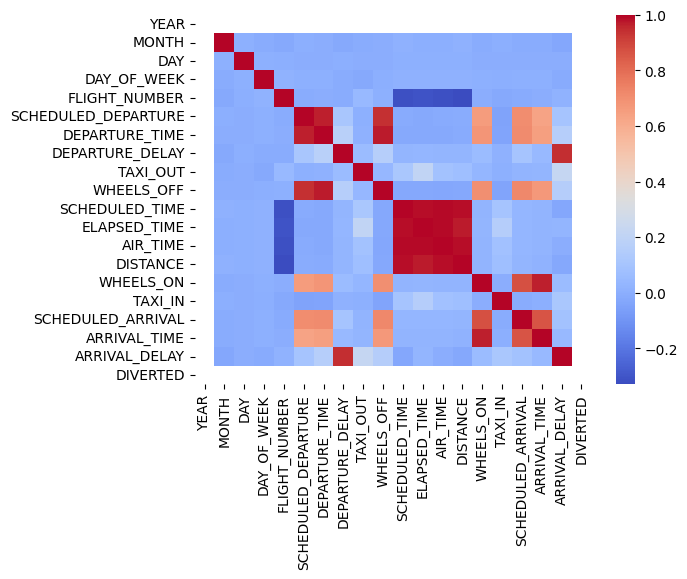

In [16]:
corr = flights_tratada.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")

### Identificação das maiores correlações

In [17]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
    .query("correlation.abs() > 0.85")
    .sort_values("correlation", ascending=False)
)

high_corr.sort_values(by="feature_1")

,feature_1,feature_2,correlation
132,AIR_TIME,DISTANCE,0.985684
97,DEPARTURE_DELAY,ARRIVAL_DELAY,0.945661
77,DEPARTURE_TIME,WHEELS_OFF,0.972563
125,ELAPSED_TIME,AIR_TIME,0.990032
126,ELAPSED_TIME,DISTANCE,0.973664
150,SCHEDULED_ARRIVAL,ARRIVAL_TIME,0.863637
62,SCHEDULED_DEPARTURE,DEPARTURE_TIME,0.964518
65,SCHEDULED_DEPARTURE,WHEELS_OFF,0.938881
118,SCHEDULED_TIME,AIR_TIME,0.990803
117,SCHEDULED_TIME,ELAPSED_TIME,0.985272


## Visualizações EDA — Insights sobre atrasos

### Taxa de atraso por mês

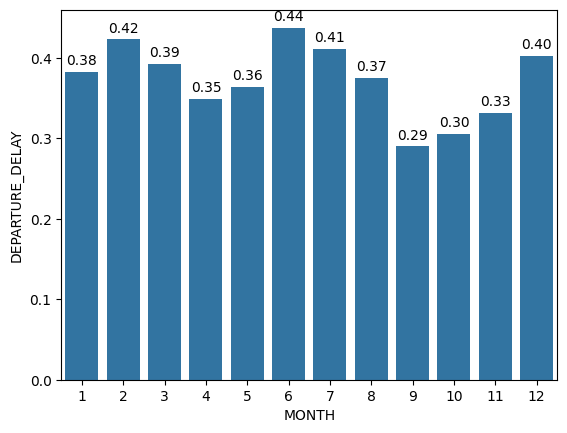

In [18]:
taxa_mes = flights_tratada.groupby('MONTH')['DEPARTURE_DELAY'].apply(lambda x: (x > 0).mean())
ax = sns.barplot(taxa_mes)
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)
plt.show()

### Taxa de atraso por dia da semana

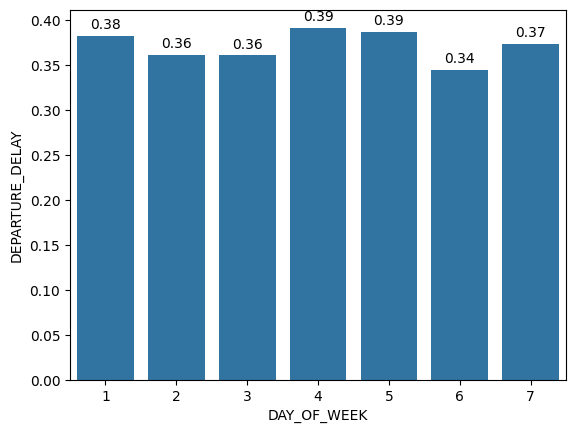

In [19]:
taxa_dia = flights_tratada.groupby('DAY_OF_WEEK')['DEPARTURE_DELAY'].apply(lambda x: (x > 0).mean())
ax = sns.barplot(taxa_dia)
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3)
plt.show()

### Top 10 companhias com maior taxa de atraso

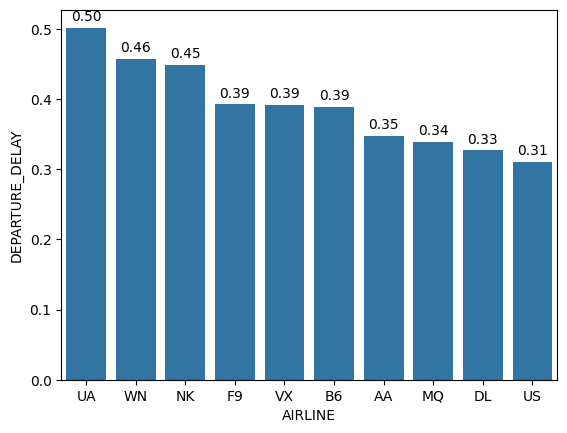

In [20]:
taxa_airline = (
    flights_tratada.groupby('AIRLINE')['DEPARTURE_DELAY']
    .apply(lambda x: (x > 0).mean())
    .sort_values(ascending=False)
).head(10)
ax = sns.barplot(taxa_airline)
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3)
plt.show()

### Top 10 aeroportos com maior taxa de atraso

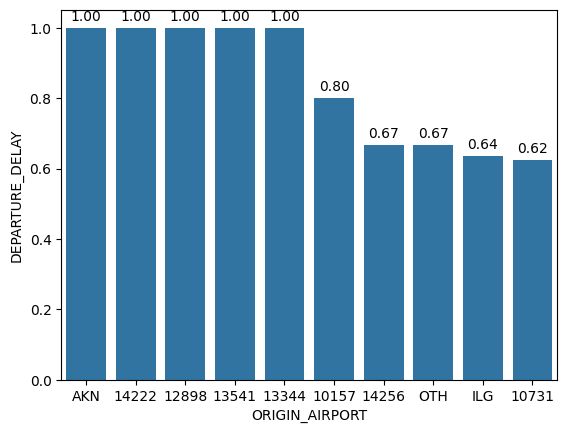

In [21]:
taxa_origem = (
    flights_tratada.groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY']
    .apply(lambda x: (x > 0).mean())
    .sort_values(ascending=False)
    .head(10)
)
ax = sns.barplot(taxa_origem)
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3)
plt.show()

### Distribuição dos atrasos de partida por período do dia

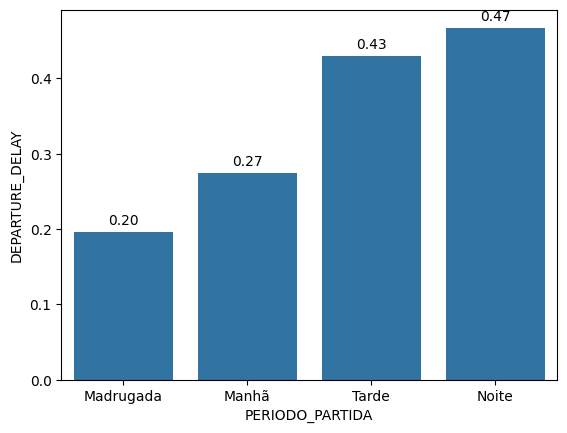

In [22]:
def periodo_do_dia(minutos):
    if minutos < 360:  return 'Madrugada'
    if minutos < 720:  return 'Manhã'
    if minutos < 1080: return 'Tarde'
    return 'Noite'

flights_tratada['PERIODO_PARTIDA'] = flights_tratada['SCHEDULED_DEPARTURE'].apply(periodo_do_dia)

ordem = ['Madrugada', 'Manhã', 'Tarde', 'Noite']
taxa_periodo = (
    flights_tratada.groupby('PERIODO_PARTIDA')['DEPARTURE_DELAY']
    .apply(lambda x: (x > 0).mean())
    .reindex(ordem)
)

ax = sns.barplot(taxa_periodo)
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3)
ax.set_label(ordem)
plt.show()

## Visualização para insights com Ydata-profilling

In [23]:
profile = ProfileReport(flights_tratada)
report_file = Path("data/output/visualizacao.html")
if report_file.exists():
    print("Report já foi gerado")
else:
    profile.to_file("data/output/visualizacao.html")

Report já foi gerado


Colunas à remover:

 - YEAR é constante
 - DIVERTED é constante e 0
 - Retirando features derivadas para evitar dataleakege
 - As colunas de horário real de chegada, de partida e de tempo total de voo são altamente relacionadas com os horários programados e são consequências dos atrasos.
 

In [24]:
flights_tratada_drop_cols = flights_tratada.drop(
    columns=[
        "YEAR",
        "DIVERTED",
        "AIR_TIME",
        "DEPARTURE_TIME",
        "ARRIVAL_TIME",
        "ELAPSED_TIME",
        "WHEELS_ON",
        "TAXI_IN",
        "DEPARTURE_DELAY",
        "ARRIVAL_DELAY",
        "TAXI_OUT",
        "WHEELS_OFF",
        "CAT_ARRIVAL_DELAY",
    ]
)


In [25]:
flights_tratada_drop_cols.shape

(285811, 14)

## Balanceamento do df

In [26]:
atrasos_partida = flights_tratada_drop_cols.query("CAT_DEPARTURE_DELAY == 'atrasado'")
sem_atraso_partida = flights_tratada_drop_cols.query(
    "CAT_DEPARTURE_DELAY != 'atrasado'"
)

sem_atraso_partida = sem_atraso_partida.sample(n=len(atrasos_partida), random_state=23)

df_partida = (
    pd.concat([atrasos_partida, sem_atraso_partida])
    .sample(frac=1, random_state=23)
    .reset_index(drop=True)
)

In [27]:
df_partida["CAT_DEPARTURE_DELAY"].value_counts()

CAT_DEPARTURE_DELAY
nao_atrasado    106301
atrasado        106301
Name: count, dtype: int64

In [28]:
df_partida

,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,CAT_DEPARTURE_DELAY,PERIODO_PARTIDA
0,9,10,4,OO,6264,N507CA,SFO,FAT,801,65.0,158,866,nao_atrasado,Tarde
1,1,22,4,US,854,N704US,PHL,DCA,1050,54.0,119,1104,atrasado,Tarde
2,11,21,6,EV,4866,N11109,IAH,SLC,555,204.0,1195,699,nao_atrasado,Manhã
3,4,22,3,B6,717,N329JB,BOS,JFK,661,78.0,187,739,nao_atrasado,Manhã
4,6,20,6,OO,6230,N767SK,COS,DEN,386,49.0,73,435,nao_atrasado,Manhã
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212597,2,28,6,WN,4153,N404WN,LAS,ONT,810,55.0,197,865,atrasado,Tarde
212598,12,30,3,AA,1929,N831AW,BUF,CLT,705,121.0,546,826,atrasado,Manhã
212599,2,22,7,AA,1679,N484AA,TPA,ORD,1033,181.0,1012,1154,atrasado,Tarde
212600,6,21,7,B6,162,N552JB,SMF,JFK,1360,320.0,2521,420,nao_atrasado,Noite


In [29]:
df_partida.columns

Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME', 'DISTANCE',
       'SCHEDULED_ARRIVAL', 'CAT_DEPARTURE_DELAY', 'PERIODO_PARTIDA'],
      dtype='object')

# MODELO SUPERVISIONADO

In [30]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

In [31]:
df_encoded = df_partida.copy()

In [32]:
le = LabelEncoder()
encoders = {}
for col in df_encoded.select_dtypes(include="object").columns:
    encoders[col] = LabelEncoder()
    df_encoded[col] = encoders[col].fit_transform(df_encoded[col].astype(str))

dict(
    zip(
        encoders["CAT_DEPARTURE_DELAY"].transform(
            encoders["CAT_DEPARTURE_DELAY"].classes_
        ),
        encoders["CAT_DEPARTURE_DELAY"].classes_,
    )
)

{np.int64(0): 'atrasado', np.int64(1): 'nao_atrasado'}

In [33]:
x = df_encoded[
    [
        "MONTH",
        "DAY",
        "DAY_OF_WEEK",
        "AIRLINE",
        "FLIGHT_NUMBER",
        "TAIL_NUMBER",
        "ORIGIN_AIRPORT",
        "DESTINATION_AIRPORT",
        "SCHEDULED_DEPARTURE",
        "SCHEDULED_TIME",
        "DISTANCE",
        "PERIODO_PARTIDA"
    ]
]

y = df_encoded[["CAT_DEPARTURE_DELAY"]]

In [34]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=23
)

## Árvore de decisão

In [35]:
modelo = DecisionTreeClassifier()
modelo.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

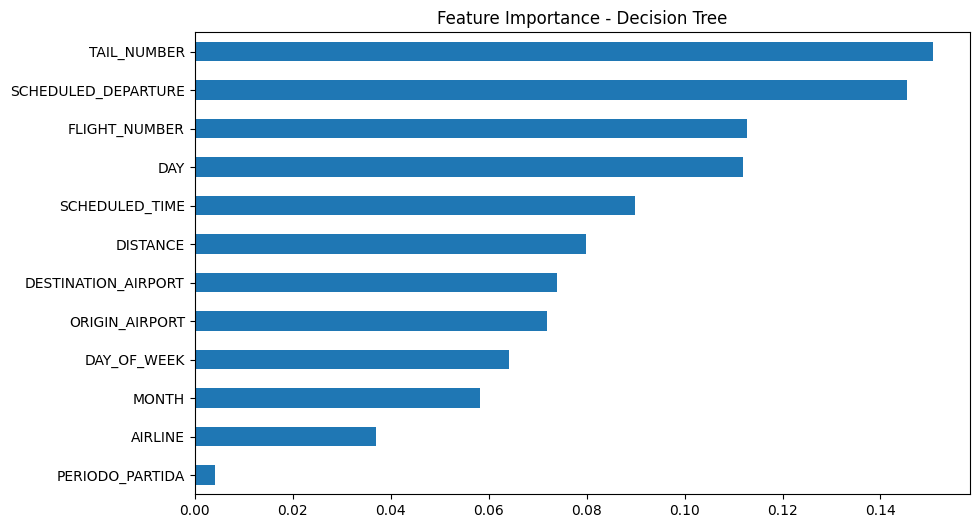

In [36]:
importancias = pd.Series(modelo.feature_importances_, index=x_train.columns)
importancias.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title('Feature Importance - Decision Tree')
plt.show()

In [37]:
y_pred = modelo.predict(x_test)

Métrica:	O que significa
 - precision	dos que o modelo disse "atrasado", quantos realmente eram
 - recall	dos que realmente eram "atrasado", quantos o modelo acertou
 - f1-score	média harmônica entre precision e recall
 - support	quantas amostras de cada classe existem no teste

In [38]:
print(classification_report(y_test, y_pred, target_names=["atrasado", "nao_atrasado"]))# type: ignore

              precision    recall  f1-score   support

    atrasado       0.56      0.55      0.56     31914
nao_atrasado       0.56      0.56      0.56     31867

    accuracy                           0.56     63781
   macro avg       0.56      0.56      0.56     63781
weighted avg       0.56      0.56      0.56     63781



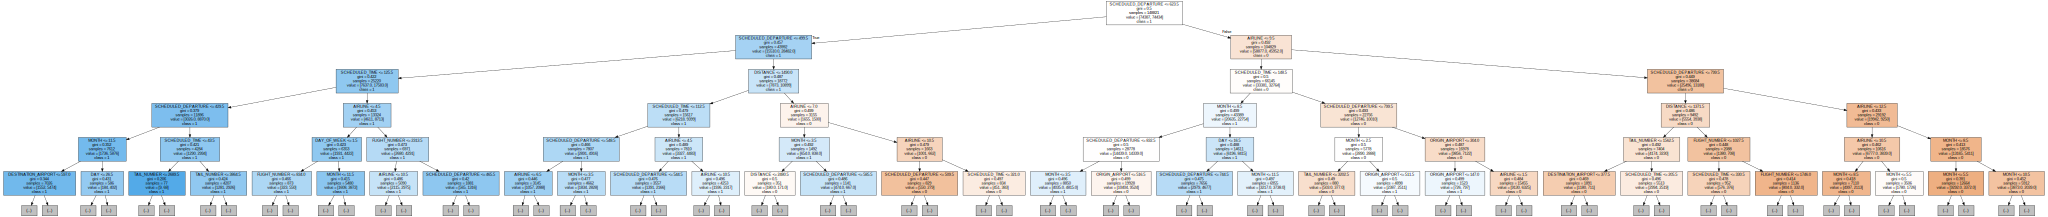

In [39]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    modelo,
    feature_names=x_train.columns,
    class_names=[str(c) for c in modelo.classes_],
    filled=True,
    max_depth=5,
)
graphviz.Source(dot_data)


## XGBoost

In [40]:
from xgboost import XGBClassifier

In [41]:
modelo_xgb = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1, n_jobs=-1, random_state=23
)

In [42]:
modelo_xgb.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [43]:
y_pred_xgb = modelo_xgb.predict(x_test)

Métrica:	O que significa
 - precision	dos que o modelo disse "atrasado", quantos realmente eram
 - recall	dos que realmente eram "atrasado", quantos o modelo acertou
 - f1-score	média harmônica entre precision e recall
 - support	quantas amostras de cada classe existem no teste

In [44]:
print(classification_report(y_test, y_pred_xgb, target_names=["atrasado", "nao_atrasado"]))

              precision    recall  f1-score   support

    atrasado       0.64      0.64      0.64     31914
nao_atrasado       0.64      0.64      0.64     31867

    accuracy                           0.64     63781
   macro avg       0.64      0.64      0.64     63781
weighted avg       0.64      0.64      0.64     63781



<Figure size 1000x600 with 0 Axes>

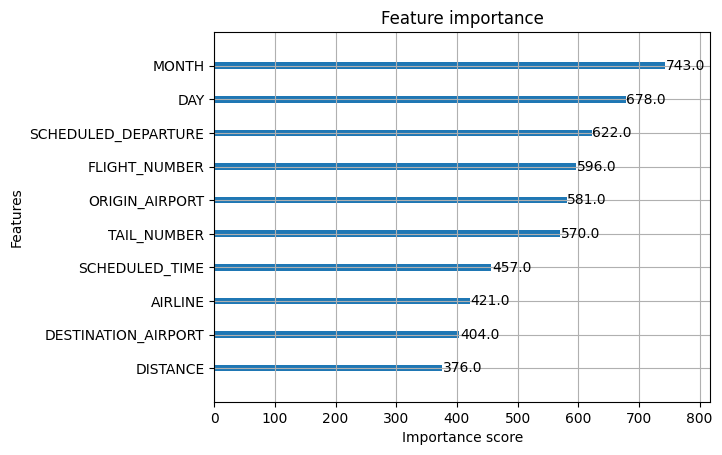

In [45]:
from xgboost import plot_importance

plt.figure(figsize=(10, 6))
plot_importance(modelo_xgb, max_num_features=10)
plt.show()


## Comparação / Conclusão

O modelo de árvore de decisões teve precisão e recall de 0.59, o que indica que o modelo acerta a maioria das vezes, porém, com uma margem não muito significativa. O modelo XGBoost acerta mais vezes 0.65 de precisão e recall trazendo maior confiabiliade.

Um achado interessante, é que para decision tree, a feature mais importante foi Tail number (numero da aeronave), que não fez muito sentindo para mim, imaginava que as variáveis aeroporto de partida, companhia aérea e horário de partida seriam mais significativas.

Com XGBoost a variável mais importante foi o mês, fazendo sentido pensando que certos meses do ano possuem mais voos e maior change de atrasos.


Para melhorar o modelo, acrescentaria dados externos de quantidade de voos planejados para aquela hora de partida, dados de clima, dados de feriados e taxa histórica de atrasos da CIA Aérea + Aeroporto. 

Não utilizei os dados acessórios de Airline e Airport, pois eles não acrescentariam adição de features impactantes.

# Modelo não supervisionado

In [46]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [47]:
perfil = (
    flights_tratada.groupby("ORIGIN_AIRPORT")
    .agg(
        taxa_atraso=("DEPARTURE_DELAY", lambda x: (x > 0).mean()),
        media_atraso=("DEPARTURE_DELAY", "mean"),
        total_voos=("DEPARTURE_DELAY", "count"),
    )
    .dropna()
)


In [48]:
perfil

,taxa_atraso,media_atraso,total_voos
ORIGIN_AIRPORT,,,
10135,0.368421,31.842105,19
10136,0.181818,2.000000,11
10140,0.361702,4.446809,94
10141,0.000000,-2.000000,1
10146,0.500000,12.500000,6
...,...,...,...
WRG,0.147059,-5.764706,34
WYS,0.000000,-2.375000,8
XNA,0.324561,13.949561,456


In [49]:
scaler = StandardScaler()
perfil_scaled = scaler.fit_transform(perfil)
perfil_scaled

array([[ 0.69381898,  1.85651168, -0.30006777],
       [-0.58559799, -0.27911889, -0.3054625 ],
       [ 0.6477516 , -0.10401466, -0.24949215],
       ...,
       [ 0.39310132,  0.57604358, -0.0053805 ],
       [-0.50517145, -1.00861346, -0.29197567],
       [-0.81933763, -0.54341902, -0.2535382 ]], shape=(616, 3))

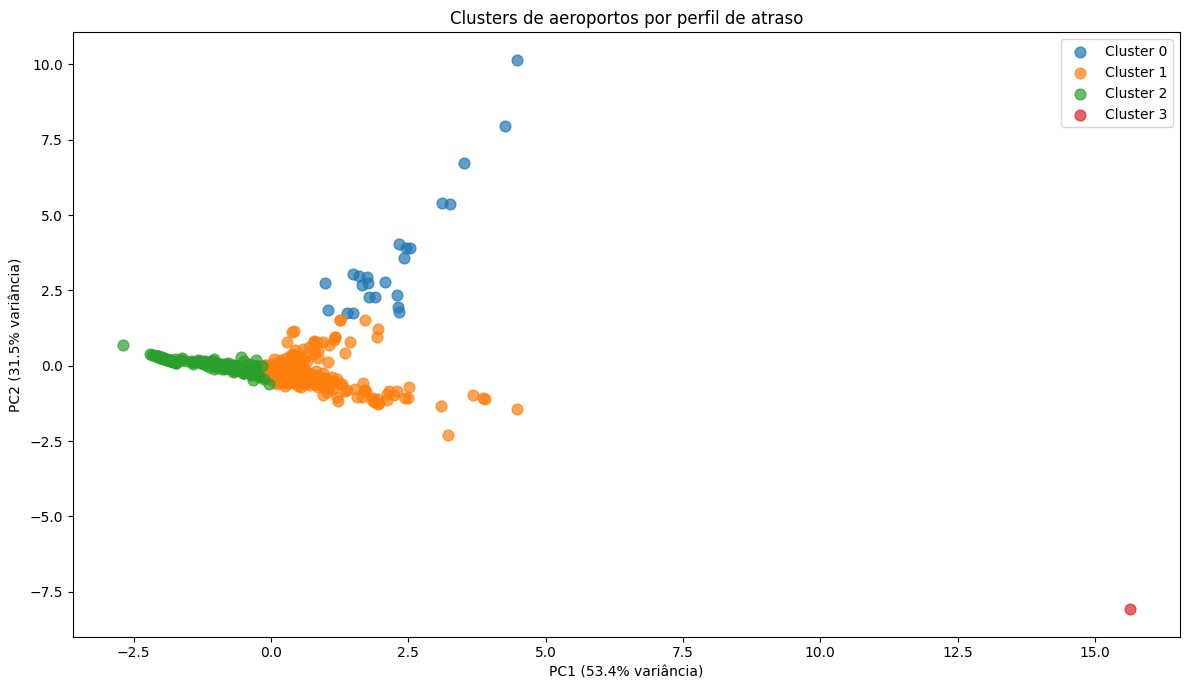

,taxa_atraso,media_atraso,total_voos
cluster,,,
0,0.40,10.57,6661.33
1,0.34,9.73,323.77
2,0.14,-1.29,51.22
3,1.00,273.00,2.00


In [ ]:

kmeans = KMeans(n_clusters=4, random_state=23)
perfil['cluster'] = kmeans.fit_predict(perfil_scaled)

# Plot com PCA 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(perfil_scaled)

plt.figure(figsize=(12, 7))
for cluster_id in sorted(perfil['cluster'].unique()):
    mask = perfil['cluster'] == cluster_id
    plt.scatter(coords[mask, 0], coords[mask, 1], label=f'Cluster {cluster_id}', alpha=0.7, s=60)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variância)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variância)')
plt.title('Clusters de aeroportos por perfil de atraso')
plt.legend()
plt.tight_layout()
plt.show()



In [51]:
# Perfil médio por cluster
print(perfil.groupby('cluster')[['taxa_atraso', 'media_atraso', 'total_voos']].mean().round(2))


         taxa_atraso  media_atraso  total_voos
cluster                                       
0               0.40         10.57     6661.33
1               0.34          9.73      323.77
2               0.14         -1.29       51.22
3               1.00        273.00        2.00


In [52]:
# Top 5 aeroportos de cada cluster
for c in sorted(perfil['cluster'].unique()):
    aeroportos = perfil[perfil['cluster'] == c].sort_values('total_voos', ascending=False).head(5)
    print(f"\n--- Cluster {c} ---")
    print(aeroportos[['taxa_atraso', 'media_atraso', 'total_voos']])



--- Cluster 0 ---
                taxa_atraso  media_atraso  total_voos
ORIGIN_AIRPORT                                       
ATL                0.380075      8.957646       17094
ORD                0.442102     14.037179       13852
DFW                0.407237     11.827075       11745
LAX                0.435526     10.920880        9593
DEN                0.465031     11.094990        9580

--- Cluster 1 ---
                taxa_atraso  media_atraso  total_voos
ORIGIN_AIRPORT                                       
MIA                0.422556     12.671967        3396
PHL                0.360834      9.936488        3212
TPA                0.371157      9.289382        3155
DAL                0.504265     11.560218        2931
HOU                0.505614     12.805652        2583

--- Cluster 2 ---
                taxa_atraso  media_atraso  total_voos
ORIGIN_AIRPORT                                       
KOA                0.248175      1.565693         548
LIH                0.2191

In [53]:
# Junta com nome da cidade para facilitar interpretação
perfil_info = perfil.join(
    airports.set_index('IATA_CODE')[['CITY', 'STATE']]
)

for c in sorted(perfil_info['cluster'].unique()):
    grupo = perfil_info[perfil_info['cluster'] == c].sort_values('total_voos', ascending=False).head(5)
    print(f"\n--- Cluster {c} (taxa média: {perfil_info[perfil_info['cluster']==c]['taxa_atraso'].mean():.1%}) ---")
    print(grupo[['CITY', 'STATE', 'taxa_atraso', 'media_atraso', 'total_voos']].to_string())



--- Cluster 0 (taxa média: 40.0%) ---
                             CITY STATE  taxa_atraso  media_atraso  total_voos
ORIGIN_AIRPORT                                                                
ATL                       Atlanta    GA     0.380075      8.957646       17094
ORD                       Chicago    IL     0.442102     14.037179       13852
DFW             Dallas-Fort Worth    TX     0.407237     11.827075       11745
LAX                   Los Angeles    CA     0.435526     10.920880        9593
DEN                        Denver    CO     0.465031     11.094990        9580

--- Cluster 1 (taxa média: 34.3%) ---
                        CITY STATE  taxa_atraso  media_atraso  total_voos
ORIGIN_AIRPORT                                                           
MIA                    Miami    FL     0.422556     12.671967        3396
PHL             Philadelphia    PA     0.360834      9.936488        3212
TPA                    Tampa    FL     0.371157      9.289382        3155